# Social Media Analytics — Lab 1

## Social Network Main Parameters: Calculation and Visualization

### 1. Dataset

For this laboratory work, the `GOT-book1.csv` dataset was selected.
The dataset represents relationships between characters from the first
book of the Game of Thrones series.

The dataset contains the following variables:

- `Source` — the source character in the relationship.
- `Target` — the target character in the relationship.
- `Type` — the type of relationship.
- `weight` — the weight or strength of the relationship.
- `book` — identifies the book associated with the relationship.

The network is treated as an undirected network because the relationships
between the characters are not directional.

In [4]:
import pandas as pd

# This is for Loading the dataset
df = pd.read_csv("/GOT-book1.csv")

# Displaying the first 5 rows
df.head()

,Source,Target,Type,weight,book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1


In [5]:
# Display the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (684, 5)

Columns:
['Source', 'Target', 'Type', 'weight', 'book']

Missing values:
Source    0
Target    0
Type      0
weight    0
book      0
dtype: int64


## 2. Data Preparation and Network Construction

The dataset contains 684 character relationships. Each relationship is
represented by a `Source` character and a `Target` character. The `weight`
variable represents the weight of the relationship.

Since the dataset represents an undirected network, the relationship
between two characters is treated as a connection between both nodes.

In [6]:
# Displaying the first 10 relationships
df.head(10)

,Source,Target,Type,weight,book
0,Addam-Marbrand,Jaime-Lannister,Undirected,3,1
1,Addam-Marbrand,Tywin-Lannister,Undirected,6,1
2,Aegon-I-Targaryen,Daenerys-Targaryen,Undirected,5,1
3,Aegon-I-Targaryen,Eddard-Stark,Undirected,4,1
4,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Undirected,4,1
5,Aemon-Targaryen-(Maester-Aemon),Bowen-Marsh,Undirected,4,1
6,Aemon-Targaryen-(Maester-Aemon),Chett,Undirected,9,1
7,Aemon-Targaryen-(Maester-Aemon),Clydas,Undirected,5,1
8,Aemon-Targaryen-(Maester-Aemon),Jeor-Mormont,Undirected,13,1
9,Aemon-Targaryen-(Maester-Aemon),Jon-Snow,Undirected,34,1


In [7]:
# Checking the type of relationships
print(df["Type"].value_counts())

# Number of unique characters
characters = set(df["Source"]).union(set(df["Target"]))

print("Number of unique characters:", len(characters))

Type
Undirected    684
Name: count, dtype: int64
Number of unique characters: 187


## 3. Network Construction

The dataset represents a weighted and undirected social network.

In the network:
- Nodes represent Game of Thrones characters.
- Edges represent relationships between characters.
- Edge weights represent the strength of the relationship.

The network is represented using an adjacency matrix and visualized as a graph.

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

In [12]:
# Creating an undirected weighted network
G = nx.from_pandas_edgelist(
    df,
    source="Source",
    target="Target",
    edge_attr="weight"
)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 187
Number of edges: 684


In [13]:
print("Is the network directed?", G.is_directed())
print("Is the network weighted?", nx.is_weighted(G))
print("Number of connected components:", nx.number_connected_components(G))


Is the network directed? False
Is the network weighted? True
Number of connected components: 1


## 4. Adjacency Matrix

An adjacency matrix represents the relationships between the nodes in the
network. Rows and columns represent the characters.

For the binary adjacency matrix:
- 1 indicates that a relationship exists between two characters.
- 0 indicates that no relationship exists.

In [14]:
# Creating binary adjacency matrix
adj_binary = nx.to_pandas_adjacency(G, weight=None)

print("Binary adjacency matrix shape:", adj_binary.shape)

adj_binary.head()

Binary adjacency matrix shape: (187, 187)


,Addam-Marbrand,Jaime-Lannister,Tywin-Lannister,Aegon-I-Targaryen,Daenerys-Targaryen,Eddard-Stark,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Bowen-Marsh,Chett,...,Lancel-Lannister,Leo-Lefford,Mace-Tyrell,Lyn-Corbray,Paxter-Redwyne,Maegor-I-Targaryen,Mord,Randyll-Tarly,Timett,Ulf-son-of-Umar
Addam-Marbrand,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Jaime-Lannister,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tywin-Lannister,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aegon-I-Targaryen,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Daenerys-Targaryen,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Weighted Adjacency Matrix

A weighted adjacency matrix retains the relationship weight from the
original dataset. A value of 0 indicates no relationship, while a
positive value represents the weight of the relationship.

In [12]:
# Creating weighted adjacency matrix
adj_weighted = nx.to_pandas_adjacency(G, weight="weight")

print("Weighted adjacency matrix shape:", adj_weighted.shape)

adj_weighted.head()

Weighted adjacency matrix shape: (187, 187)


,Addam-Marbrand,Jaime-Lannister,Tywin-Lannister,Aegon-I-Targaryen,Daenerys-Targaryen,Eddard-Stark,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Bowen-Marsh,Chett,...,Lancel-Lannister,Leo-Lefford,Mace-Tyrell,Lyn-Corbray,Paxter-Redwyne,Maegor-I-Targaryen,Mord,Randyll-Tarly,Timett,Ulf-son-of-Umar
Addam-Marbrand,0.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Jaime-Lannister,3.0,0.0,16.0,0.0,0.0,27.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tywin-Lannister,6.0,16.0,0.0,0.0,0.0,18.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Aegon-I-Targaryen,0.0,0.0,0.0,0.0,5.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Daenerys-Targaryen,0.0,0.0,0.0,5.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
# Checking the relationship between Aemon-Targaryen-(Maester-Aemon) and Jon-Snow

node1 = "Aemon-Targaryen-(Maester-Aemon)"
node2 = "Jon-Snow"

print("Binary value:", adj_binary.loc[node1, node2])
print("Weighted value:", adj_weighted.loc[node1, node2])

Binary value: 1.0
Weighted value: 34.0


## 5. Network Visualization

The Game of Thrones character relationships are visualized as a network.
Each node represents a character and each edge represents a relationship
between two characters.

The size of each node is based on its degree, so characters with more
direct connections appear larger.

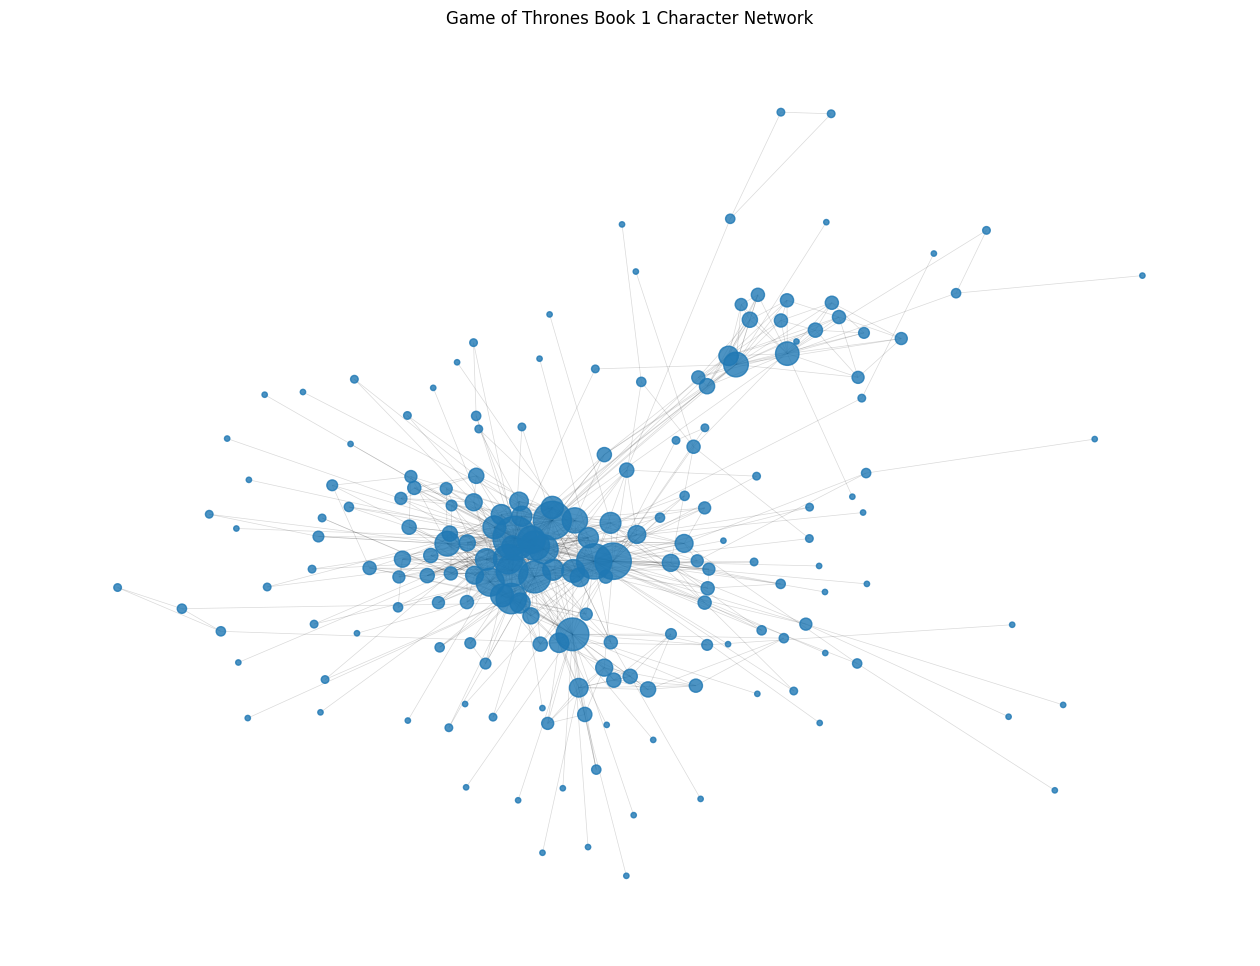

In [15]:
# Calculate degree for each node
degree = dict(G.degree())

# Create network layout
pos = nx.spring_layout(G, seed=42, k=0.4)

# Draw the network
plt.figure(figsize=(16, 12))

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.15,
    width=0.5
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=[degree[node] * 15 for node in G.nodes()],
    alpha=0.8
)

plt.title("Game of Thrones Book 1 Character Network")
plt.axis("off")
plt.show()

### Interpretation

The visualization shows the structure of the Game of Thrones Book 1
character network. Each node represents a character and each edge
represents a relationship between two characters. Node sizes are
proportional to degree, meaning that characters with more direct
connections appear larger.

The visualization shows a densely connected central region together with
nodes that have fewer direct connections and are positioned farther from
the main cluster.

## 6. Node Parameters

### 6.1 Degree

Degree centrality represents the number of direct connections of a node.
In this analysis, degree is calculated for every character in the
undirected network.

In [16]:
# Calculate degree for every node
degree = dict(G.degree())

# Create a DataFrame
degree_df = pd.DataFrame(
    degree.items(),
    columns=["Character", "Degree"]
)

# Sort from highest to lowest degree
degree_df = degree_df.sort_values(
    by="Degree",
    ascending=False
)

# Display the 10 characters with the highest degree
degree_df.head(10)

,Character,Degree
5,Eddard-Stark,66
18,Robert-Baratheon,50
30,Tyrion-Lannister,46
39,Catelyn-Stark,43
12,Jon-Snow,37
54,Sansa-Stark,35
51,Robb-Stark,35
38,Bran-Stark,32
44,Joffrey-Baratheon,30
40,Cersei-Lannister,30


The character with the highest degree is Eddard Stark, with 66 direct connections.

Followed by:

Robert Baratheon : 50
Tyrion Lannister : 46

This indicates that Eddard Stark has the largest number of direct relationships in the network.

### 6.2 Distance

Distance represents the minimum number of edges required to travel from
one node to another in the network.

For the Game of Thrones character network, shortest-path distances are
calculated between all pairs of characters.

In [17]:
# Calculate shortest-path distance between every pair of characters
distance_matrix = pd.DataFrame(
    dict(nx.all_pairs_shortest_path_length(G))
)

# Arrange rows and columns in the same order
distance_matrix = distance_matrix.loc[
    list(G.nodes()),
    list(G.nodes())
]

print("Distance matrix shape:", distance_matrix.shape)

distance_matrix.iloc[:10, :10]

Distance matrix shape: (187, 187)


,Addam-Marbrand,Jaime-Lannister,Tywin-Lannister,Aegon-I-Targaryen,Daenerys-Targaryen,Eddard-Stark,Aemon-Targaryen-(Maester-Aemon),Alliser-Thorne,Bowen-Marsh,Chett
Addam-Marbrand,0,1,1,3,3,2,4,3,4,4
Jaime-Lannister,1,0,1,2,2,1,3,2,3,3
Tywin-Lannister,1,1,0,2,2,1,3,2,3,3
Aegon-I-Targaryen,3,2,2,0,1,1,3,3,3,3
Daenerys-Targaryen,3,2,2,1,0,1,3,3,3,3
Eddard-Stark,2,1,1,1,1,0,2,2,2,2
Aemon-Targaryen-(Maester-Aemon),4,3,3,3,3,2,0,1,1,1
Alliser-Thorne,3,2,2,3,3,2,1,0,1,2
Bowen-Marsh,4,3,3,3,3,2,1,1,0,2
Chett,4,3,3,3,3,2,1,2,2,0


### 6.3 Closeness

Closeness centrality reflects how accessible a node is within the network.
It is based on the distances between a node and the other nodes in the
network. A larger closeness value indicates that the node is better
connected to the other nodes.

In [18]:
# Calculate closeness centrality
closeness = nx.closeness_centrality(G)

# Create a DataFrame
closeness_df = pd.DataFrame(
    closeness.items(),
    columns=["Character", "Closeness"]
)

# Sort from highest to lowest
closeness_df = closeness_df.sort_values(
    by="Closeness",
    ascending=False
)

# Display the 10 characters with the highest closeness
closeness_df.head(10)

,Character,Closeness
5,Eddard-Stark,0.563636
18,Robert-Baratheon,0.545455
30,Tyrion-Lannister,0.510989
39,Catelyn-Stark,0.505435
51,Robb-Stark,0.497326
12,Jon-Snow,0.493369
54,Sansa-Stark,0.489474
38,Bran-Stark,0.486911
40,Cersei-Lannister,0.484375
44,Joffrey-Baratheon,0.480620


### 6.4 Betweenness Centrality

Betweenness centrality measures the degree to which information has to
flow through a particular node in the network. It therefore provides
information about the position of a node within the network.

In [19]:
# Calculate betweenness centrality
betweenness = nx.betweenness_centrality(G)

# Create a DataFrame
betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=["Character", "Betweenness"]
)

# Sort from highest to lowest
betweenness_df = betweenness_df.sort_values(
    by="Betweenness",
    ascending=False
)

# Display the 10 characters with the highest betweenness
betweenness_df.head(10)

,Character,Betweenness
5,Eddard-Stark,0.269604
18,Robert-Baratheon,0.214030
30,Tyrion-Lannister,0.190212
12,Jon-Snow,0.171581
39,Catelyn-Stark,0.151395
4,Daenerys-Targaryen,0.086270
51,Robb-Stark,0.072984
20,Drogo,0.064812
38,Bran-Stark,0.055800
54,Sansa-Stark,0.037145


### 6.5 Clustering Coefficient

The clustering coefficient measures the tendency of a node to be included
in a triad. It describes how strongly the neighbors of a node are
connected to each other.

In [20]:
# Calculate clustering coefficient for every node
clustering = nx.clustering(G)

# Create a DataFrame
clustering_df = pd.DataFrame(
    clustering.items(),
    columns=["Character", "Clustering_Coefficient"]
)

# Sort from highest to lowest
clustering_df = clustering_df.sort_values(
    by="Clustering_Coefficient",
    ascending=False
)

# Display the 10 characters with the highest clustering coefficient
clustering_df.head(10)

,Character,Clustering_Coefficient
0,Addam-Marbrand,1.0
8,Bowen-Marsh,1.0
3,Aegon-I-Targaryen,1.0
9,Chett,1.0
25,Albett,1.0
47,Mycah,1.0
41,Desmond,1.0
57,Vayon-Poole,1.0
113,Janos-Slynt,1.0
109,Stevron-Frey,1.0


## 7. Summary of Node Parameters

The calculated node parameters are combined into one table to allow the
network characteristics of individual characters to be examined using
different measures.

In [21]:
# Combine all node parameters
node_parameters = degree_df.merge(
    closeness_df,
    on="Character"
).merge(
    betweenness_df,
    on="Character"
).merge(
    clustering_df,
    on="Character"
)

# Sort by degree
node_parameters = node_parameters.sort_values(
    by="Degree",
    ascending=False
)

# Display the top 15 characters
node_parameters.head(15)

,Character,Degree,Closeness,Betweenness,Clustering_Coefficient
0,Eddard-Stark,66,0.563636,0.269604,0.132867
1,Robert-Baratheon,50,0.545455,0.214030,0.212245
2,Tyrion-Lannister,46,0.510989,0.190212,0.180676
3,Catelyn-Stark,43,0.505435,0.151395,0.193798
4,Jon-Snow,37,0.493369,0.171581,0.210210
5,Sansa-Stark,35,0.489474,0.037145,0.334454
6,Robb-Stark,35,0.497326,0.072984,0.258824
7,Bran-Stark,32,0.486911,0.055800,0.300403
8,Joffrey-Baratheon,30,0.480620,0.018949,0.420690
9,Cersei-Lannister,30,0.484375,0.026435,0.411494


## 8. Network Parameters

### 8.1 Diameter

The diameter of a network is the longest of all the shortest-path
distances between pairs of nodes.

In [22]:
# Calculate network diameter
diameter = nx.diameter(G)

print("Network diameter:", diameter)

Network diameter: 7


### 8.2 Network Centralization

Network centralization describes how much the network's centrality is
concentrated around particular nodes.

In this analysis, degree centralization is calculated using the degree
values of the nodes. A highly centralized network has one or a few nodes
that are substantially more central than the others.

In [23]:
# Calculate degree centralization

degrees = dict(G.degree())

max_degree = max(degrees.values())

degree_centralization = sum(
    max_degree - degree
    for degree in degrees.values()
)

n = G.number_of_nodes()

# Freeman degree centralization normalization
max_possible = (n - 1) * (n - 2)

degree_centralization_normalized = (
    degree_centralization / max_possible
)

print("Degree centralization:", degree_centralization_normalized)

Degree centralization: 0.31891891891891894


### 8.3 Cliques

A clique is a subset of nodes in which every pair of nodes is connected.
Cliques therefore represent fully connected groups within the network.

In [24]:
# Find all cliques in the network
cliques = list(nx.find_cliques(G))

print("Number of cliques:", len(cliques))

# Find the largest clique
largest_clique = max(cliques, key=len)

print("Largest clique size:", len(largest_clique))
print("Largest clique:", largest_clique)

Number of cliques: 245
Largest clique size: 10
Largest clique: ['Eddard-Stark', 'Robert-Baratheon', 'Sansa-Stark', 'Joffrey-Baratheon', 'Cersei-Lannister', 'Petyr-Baelish', 'Renly-Baratheon', 'Barristan-Selmy', 'Varys', 'Pycelle']


In [25]:
from collections import Counter

clique_sizes = Counter(len(clique) for clique in cliques)

print("Clique size distribution:")
for size in sorted(clique_sizes):
    print(f"Size {size}: {clique_sizes[size]} cliques")

Clique size distribution:
Size 2: 54 cliques
Size 3: 34 cliques
Size 4: 32 cliques
Size 5: 30 cliques
Size 6: 38 cliques
Size 7: 14 cliques
Size 8: 25 cliques
Size 9: 12 cliques
Size 10: 6 cliques


### 8.4 Network Clustering Coefficient

The network clustering coefficient expresses the probability that
connected triples of nodes form triangles. It provides a measure of
the overall tendency of the network to contain tightly connected
groups of nodes.

In [26]:
# Calculate the average clustering coefficient of the network
network_clustering = nx.average_clustering(G)

print("Network clustering coefficient:", network_clustering)

Network clustering coefficient: 0.5121189412047715


In [27]:
# Calculate network modularity

from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community import modularity

communities = list(greedy_modularity_communities(G))

network_modularity = modularity(G, communities)

print("Number of communities:", len(communities))
print("Network modularity:", network_modularity)

Number of communities: 7
Network modularity: 0.43517968129872053


### 9. Summary of Network Parameters

The following table summarizes the main network-level parameters calculated
for the Game of Thrones Book 1 character network.

In [28]:
# Summary of network parameters

network_parameters = pd.DataFrame({
    "Parameter": [
        "Number of nodes",
        "Number of edges",
        "Connected components",
        "Diameter",
        "Degree centralization",
        "Number of maximal cliques",
        "Largest clique size",
        "Network clustering coefficient",
        "Number of communities",
        "Modularity"
    ],
    "Value": [
        G.number_of_nodes(),
        G.number_of_edges(),
        nx.number_connected_components(G),
        diameter,
        round(degree_centralization_normalized, 4),
        len(cliques),
        len(largest_clique),
        round(network_clustering, 4),
        len(communities),
        round(network_modularity, 4)
    ]
})

network_parameters

,Parameter,Value
0,Number of nodes,187.0000
1,Number of edges,684.0000
2,Connected components,1.0000
3,Diameter,7.0000
4,Degree centralization,0.3189
5,Number of maximal cliques,245.0000
6,Largest clique size,10.0000
7,Network clustering coefficient,0.5121
8,Number of communities,7.0000
9,Modularity,0.4352


### 10. Summary of Node Parameters

The following table combines the calculated node-level parameters:
degree, closeness, betweenness centrality, and clustering coefficient.

In [29]:
# Combine node-level parameters

node_parameters = (
    degree_df
    .merge(closeness_df, on="Character")
    .merge(betweenness_df, on="Character")
    .merge(clustering_df, on="Character")
)

node_parameters = node_parameters.sort_values(
    by="Degree",
    ascending=False
)

node_parameters.head(15)

,Character,Degree,Closeness,Betweenness,Clustering_Coefficient
0,Eddard-Stark,66,0.563636,0.269604,0.132867
1,Robert-Baratheon,50,0.545455,0.214030,0.212245
2,Tyrion-Lannister,46,0.510989,0.190212,0.180676
3,Catelyn-Stark,43,0.505435,0.151395,0.193798
4,Jon-Snow,37,0.493369,0.171581,0.210210
5,Sansa-Stark,35,0.489474,0.037145,0.334454
6,Robb-Stark,35,0.497326,0.072984,0.258824
7,Bran-Stark,32,0.486911,0.055800,0.300403
8,Joffrey-Baratheon,30,0.480620,0.018949,0.420690
9,Cersei-Lannister,30,0.484375,0.026435,0.411494


# Final Analysis and Interpretation

## Dataset Explanation

The selected dataset is `GOT-book1.csv`, which describes interactions
between characters from the first book of the *A Song of Ice and Fire*
series. Each record represents a relationship between two characters.

The resulting network consists of **187 nodes and 684 edges**. Each node
corresponds to a character, while an edge represents a relationship between
two characters. The relationships are undirected, meaning that the
connections do not have a specified direction.

The dataset also contains a weight attribute for the relationships.
Therefore, a binary adjacency matrix and a weighted adjacency matrix were
constructed. The binary matrix indicates whether a direct connection
exists between two characters, while the weighted matrix retains the
relationship weight.

## Node Parameter Analysis

Five node-level parameters were considered: degree, distance, closeness,
betweenness centrality, and clustering coefficient.

**Degree** indicates the number of direct connections associated with a
character.

**Distance** represents the shortest path between two nodes, measured by
the number of edges along that path.

**Closeness** describes how accessible a node is to the other nodes in the
network.

**Betweenness centrality** describes the extent to which a node occurs on
shortest paths connecting other nodes.

**Clustering coefficient** measures the tendency of a node's connected
neighbours to also be connected to one another.

Among the characters examined, **Eddard-Stark** has the highest degree,
with **66 direct connections**. He also has the highest closeness value of
**0.563636** and the highest betweenness centrality of **0.269604**.

Other characters with relatively high degree values include
**Robert-Baratheon (50)**, **Tyrion-Lannister (46)**,
**Catelyn-Stark (43)**, and **Jon-Snow (37)**.

The clustering coefficient provides a different perspective from the
other centrality measures. For example, **Petyr-Baelish** has a clustering
coefficient of **0.476923**, while **Cersei-Lannister** has **0.411494**.
A high clustering coefficient indicates strong local interconnectedness
among a node's neighbours and does not by itself indicate high overall
network centrality.

## Network Parameter Analysis

The calculated **network diameter is 7**. This means that the greatest
shortest-path distance found between two nodes in the network is seven
edges.

The **degree centralization is 0.3189**. This value describes the extent
to which the network's degree distribution is concentrated around highly
connected nodes.

The analysis identified **245 maximal cliques**, with the largest clique
containing **10 characters**. A clique represents a group in which every
pair of nodes is directly connected.

The **network clustering coefficient is 0.5121**. This indicates a
noticeable tendency for connected triples within the network to form
triangles, reflecting local interconnectedness.

Community detection identified **7 communities**, producing a **modularity
value of 0.4352**. This shows that the network contains a discernible
community structure, with connections within groups contributing to the
observed modular organization.

## Conclusion

The analysis of the Game of Thrones Book 1 network shows how graph-based
measures can be used to examine relationships between characters.

The network contains **187 characters and 684 relationships** and forms a
single connected component. The node-level measures highlight differences
in direct connectivity, accessibility, intermediary position, and local
neighbourhood structure.

Eddard-Stark has the highest degree, closeness, and betweenness centrality
among the calculated results. At the network level, the diameter of **7**,
degree centralization of **0.3189**, clustering coefficient of **0.5121**,
and modularity of **0.4352** provide different views of the overall
network structure.

The identification of **7 communities** and a largest clique of **10
characters** further demonstrates the presence of interconnected groups
within the network.

Overall, the analysis demonstrates the use of social network analysis
parameters to examine both the position of individual nodes and the
structural characteristics of the network as a whole.